In [5]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

zip_path="/content/Plant_Disease_Workshop.zip"
extract_path="/content"
with zipfile.ZipFile(zip_path,'r') as zip_ref:
  zip_ref.extractall(extract_path)
print("Dataset Extracted successfully!")


Dataset Extracted successfully!


In [6]:
print(os.listdir("/content"))

['.config', 'Plant_Disease_Workshop', 'Plant_Disease_Workshop.zip', 'sample_data']


In [7]:
dataset_path="/content/Plant_Disease_Workshop"
print(os.listdir(dataset_path))

['val', 'train']


In [8]:
train_path="/content/Plant_Disease_Workshop/train"
print(os.listdir(dataset_path))

['val', 'train']


In [9]:
val_path="/content/Plant_Disease_Workshop/val"
print(os.listdir(dataset_path))

['val', 'train']


In [10]:
print("============== TRAIN DATA=============")
for folder in os.listdir(train_path):
  folder_path=os.path.join(train_path,folder)
  print(folder,':',len(os.listdir(folder_path)),'images')


print("\n============== VAL  DATA============\n")
for folder in os.listdir(val_path):
  folder_path=os.path.join(val_path,folder)
  print(folder,':',len(os.listdir(folder_path)),'images')

============== TRAIN DATA=============
Potato___Early_blight : 800 images
Potato___Late_blight : 800 images
Potato___healthy : 121 images

============== VAL  DATA============

Potato___Early_blight : 200 images
Potato___Late_blight : 200 images
Potato___healthy : 31 images


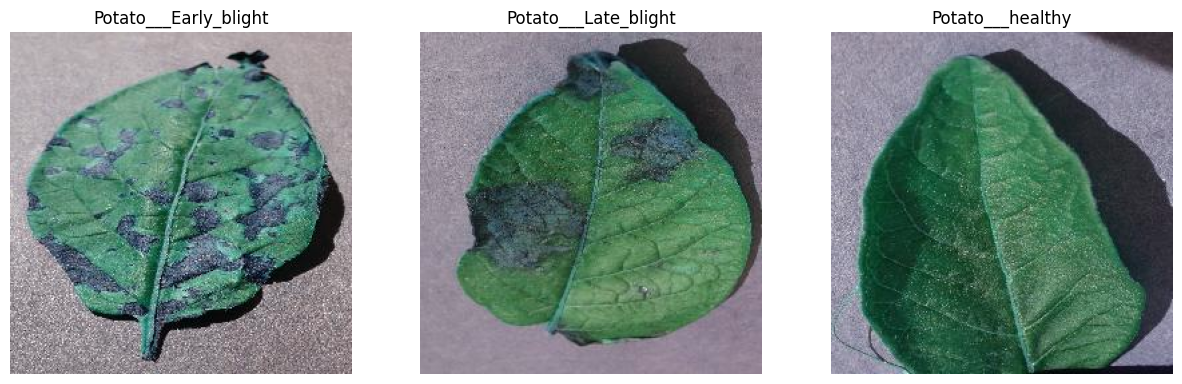

In [11]:
plt.figure(figsize=(15,5))
classes = os.listdir(train_path)
for i, folder in enumerate(classes):
  image_name = os.listdir(os.path.join(train_path,folder))[0]
  image_path = os.path.join(train_path,folder,image_name)
  image = cv2.imread(image_path)
  image - cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  plt.subplot(1,3,i+1)
  plt.imshow(image)
  plt.title(folder)
  plt.axis("off")
plt.show()


In [12]:
train_path='/content/Plant_Disease_Workshop/train'
val_path='/content/Plant_Disease_Workshop/val'
image_size=(64,64)

In [13]:
X_train=[]
y_train=[]

X_val=[]
y_val=[]

In [14]:
for label in os.listdir(train_path):
  folder_path=os.path.join(train_path,label)
  for image_name in os.listdir(folder_path):
    image_path=os.path.join(folder_path,image_name)
    image=cv2.imread(image_path)
    image=cv2.resize(image,image_size)
    X_train.append(image)
    y_train.append(label)
print("Train image Loaded Successfully!")

Train image Loaded Successfully!


In [15]:
for label in os.listdir(val_path):
  folder_path=os.path.join(val_path,label)
  for image_name in os.listdir(folder_path):
    image_path=os.path.join(folder_path,image_name)
    image=cv2.imread(image_path)
    image=cv2.resize(image,image_size)
    X_val.append(image)
    y_val.append(label)
print("Valization image Loaded Successfully!")

Valization image Loaded Successfully!


In [16]:
print("Training images:",len(X_train))
print("Training labels:",len(y_train))

print()

print("Validation images:",len(X_val))
print("Validation labels:",len(y_val))

Training images: 1721
Training labels: 1721

Validation images: 431
Validation labels: 431


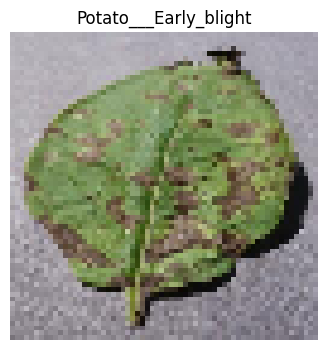

In [17]:
plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(X_train[0],cv2.COLOR_BGR2RGB))
plt.title(y_train[0])
plt.axis("off")
plt.show()

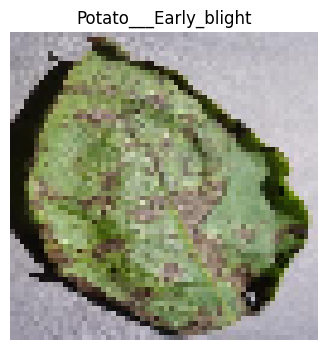

In [18]:
plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(X_val[0],cv2.COLOR_BGR2RGB))
plt.title(y_train[0])
plt.axis("off")
plt.show()

In [19]:
X_train=np.array(X_train)
X_val=np.array(X_val)
y_train=np.array(y_train)
y_val=np.array(y_val)
print("Converted Successufully!")

Converted Successufully!


In [20]:
print("Training Shape:",X_train.shape)
print("Validation Shape:",X_val.shape)

Training Shape: (1721, 64, 64, 3)
Validation Shape: (431, 64, 64, 3)


In [21]:
X_train=X_train.reshape(X_train.shape[0],-1)
X_val=X_val.reshape(X_val.shape[0],-1)
print("Image reshape successfullfy!")

Image reshape successfullfy!


In [22]:
X_train=X_train / 255.0
X_val=X_val / 255.0
print("Image Normalize successfullfy!")

Image Normalize successfullfy!


In [23]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_val = encoder.fit_transform(y_val)
print("Label Encoder successfullfy!")

Label Encoder successfullfy!


In [24]:
print("Encoder classes")
print(encoder.classes_)

print()

print("First 10 Labels:")
print(y_train[:10])

Encoder classes
['Potato___Early_blight' 'Potato___Late_blight' 'Potato___healthy']

First 10 Labels:
[0 0 0 0 0 0 0 0 0 0]


In [25]:
print("Training Features Shape",X_train.shape)
print("Training Labels Shape",y_train.shape)

print()

print("Validation Features Shape",X_val.shape)
print("Validation Labels Shape",y_val.shape)

Training Features Shape (1721, 12288)
Training Labels Shape (1721,)

Validation Features Shape (431, 12288)
Validation Labels Shape (431,)


In [26]:
logistic_model = LogisticRegression(max_iter=1000)
print("Logistic Regression Model created Successfully!")

Logistic Regression Model created Successfully!


In [27]:
logistic_model.fit(X_train,y_train)
print("Model Training is completed!")

Model Training is completed!


In [28]:
y_pred=logistic_model.predict(X_val)
print("Prediction Completed")

Prediction Completed


In [29]:
print("Actual label:",y_val[:10])
print("Predicted label:",y_pred[:10])

Actual label: [0 0 0 0 0 0 0 0 0 0]
Predicted label: [0 0 0 0 0 0 0 0 0 0]


In [30]:
acc =accuracy_score(y_val, y_pred)
print("accuracy score:",round(acc * 100, 2),"%")

accuracy score: 90.72 %


In [31]:
cmx = confusion_matrix(y_val, y_pred)
print(cmx)

[[185  15   0]
 [  8 189   3]
 [  0  14  17]]


In [32]:
print(classification_report(y_val, y_pred, target_names=encoder.classes_))

                       precision    recall  f1-score   support

Potato___Early_blight       0.96      0.93      0.94       200
 Potato___Late_blight       0.87      0.94      0.90       200
     Potato___healthy       0.85      0.55      0.67        31

             accuracy                           0.91       431
            macro avg       0.89      0.81      0.84       431
         weighted avg       0.91      0.91      0.90       431



In [33]:
predicted_labels = encoder.inverse_transform(y_pred[:10])
print("First 10 predicted Disease Names:")
print(predicted_labels)

First 10 predicted Disease Names:
['Potato___Early_blight' 'Potato___Early_blight' 'Potato___Early_blight'
 'Potato___Early_blight' 'Potato___Early_blight' 'Potato___Early_blight'
 'Potato___Early_blight' 'Potato___Early_blight' 'Potato___Early_blight'
 'Potato___Early_blight']


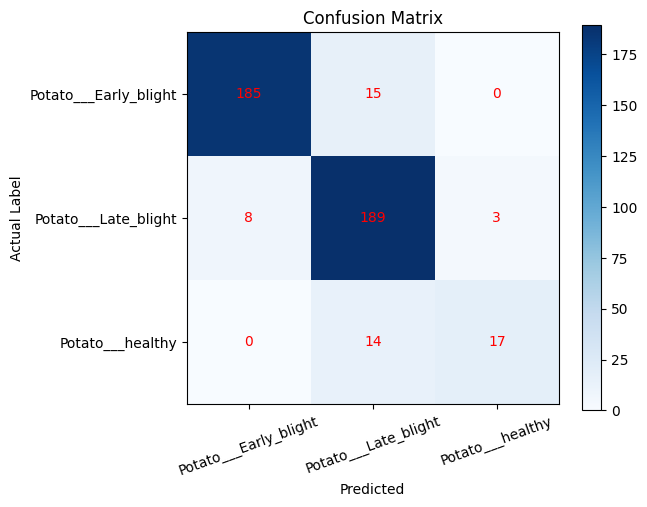

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(cmx, cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(3), encoder.classes_, rotation=20)
plt.yticks(range(3), encoder.classes_)

for i in range(3):
    for j in range(3):
        plt.text(j, i, cmx[i, j],
                 ha='center',
                 va='center',
                 color="red")

plt.xlabel('Predicted')
plt.ylabel('Actual Label')

plt.show()

In [35]:
print("="*40)
print("Logistic Regression completed successfully!")
print("="*40)

print(f"Accuracy: {acc * 100:.2f}%")

Logistic Regression completed successfully!
Accuracy: 90.72%


In [36]:
svm_model = SVC(kernel="linear")
print("SVM Model created Successfully!")


SVM Model created Successfully!


In [37]:
svm_model.fit(X_train,y_train)
print("Model Training is completed!")

Model Training is completed!


In [38]:
y_pred = svm_model.predict(X_val)
print("Prediction Completed")

Prediction Completed


In [39]:
svm_acc = accuracy_score(y_val, y_pred)
print("accuracy score:", round(svm_acc * 100, 2), "%")

accuracy score: 91.18 %


In [40]:
svm_cm = confusion_matrix(y_val, y_pred)
print(cmx)

[[185  15   0]
 [  8 189   3]
 [  0  14  17]]


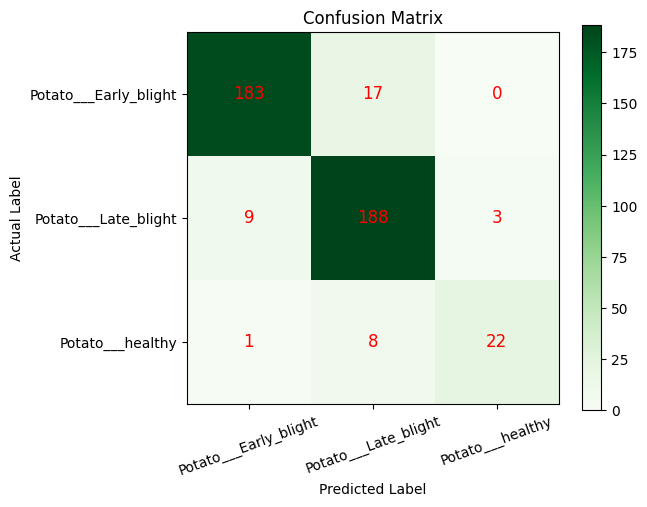

In [41]:
plt.figure(figsize=(6, 5))
plt.imshow(svm_cm, cmap='Greens')
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(3), encoder.classes_, rotation=20)
plt.yticks(range(3), encoder.classes_)

for i in range(len(svm_cm)):
    for j in range(len(svm_cm)):
        plt.text(j, i, svm_cm[i, j],
                 ha='center',
                 va='center',
                 color="red",
                 fontsize=12)
        plt.xlabel('Predicted Label')
        plt.ylabel('Actual Label')

plt.show()

In [44]:
from google.colab import files
uploaded=files.upload()

Saving can-you-eat-potato-leaves.jpg to can-you-eat-potato-leaves.jpg


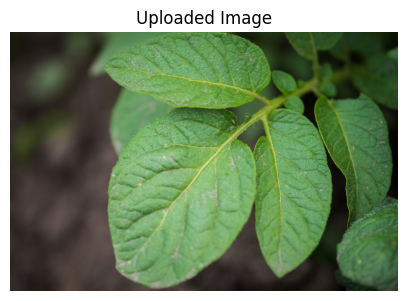

In [45]:
image_name=list(uploaded.keys())[0]
image=cv2.imread(image_name)
image_rgb=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5,5))
plt.imshow(image_rgb)
plt.title("Uploaded Image")
plt.axis('off')
plt.show()

In [46]:
test_image=cv2.resize(image,(64,64))
test_image=test_image.reshape(1,-1)
test_image=test_image/255.0
print("Image Processed succesfully")

Image Processed succesfully


In [47]:
prediction = svm_model.predict(test_image)
predicted_disease = encoder.inverse_transform(prediction)
print("Predicted Disease:", predicted_disease[0])

Predicted Disease: Potato___Late_blight


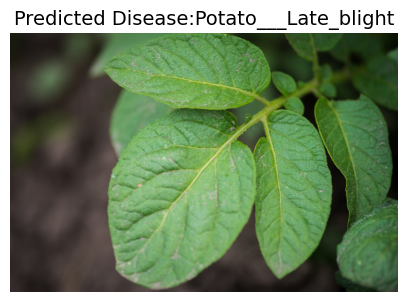

In [48]:
plt.figure(figsize=(5,5))
plt.imshow(image_rgb)
plt.title("Predicted Disease:"+predicted_disease[0], fontsize=14)
plt.axis('off')
plt.show()

In [49]:
if predicted_disease[0]=='Potato___Early_blight':
  print("Disease : Early Blight")
  print("Advice:Remove infected leaves and apply a suitable fungicies")

elif predicted_disease[0]=='Potato___Late_blight':
  print("Disease : Late Blight")
  print("Advice: Remove infected leaves and apply fungicide.")

else:
  print("Disease: Healthy")
  print("Advice: No disease detected.continue regular crop care.")

Disease : Late Blight
Advice: Remove infected leaves and apply fungicide.


In [50]:
comparison = {
    "model": ["Logistic Regression", "Support Vector Machine"],
    "accuracy": [acc* 100, svm_acc* 100]
}
import pandas as pd

comparison_df = pd.DataFrame(comparison)
comparison_df

,model,accuracy
0,Logistic Regression,90.719258
1,Support Vector Machine,91.183295


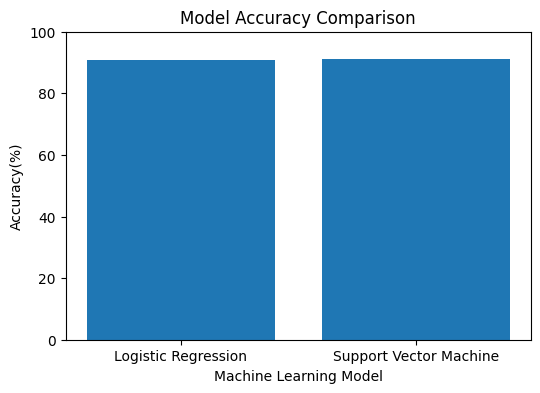

In [54]:
plt.figure(figsize=(6,4))
plt.bar(comparison_df['model'],comparison_df['accuracy'])
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy(%)")
plt.ylim(0,100)
plt.show()

In [56]:
if acc > svm_acc:
  print("Best Model: Logistic regression")
else:
  print("Best Model: support vector Machine(SVM)")

Best Model: support vector Machine(SVM)
